In [ ]:
import os
import os.path as op
import shutil
from glob import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
import cv2
import random

In [ ]:
import torch
import fastai
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from fastai.vision.all import *
from fastai.vision.augment import *
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [ ]:
!pip install -Uqq fastbook
import fastbook
fastbook.setup_book()
from fastbook import *

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 22.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 57.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.2/486.2 kB 47.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 63.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.5/110.5 kB 14.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.5/212.5 kB 24.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.3/134.3 kB 16.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.8/268.8 kB 30.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 85.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 50.8 MB/s eta 0:00:00
Mounted at /content/gdrive


In [ ]:
from fastai import *

In [ ]:
dir(models)

In [ ]:

fields = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    get_y=parent_label,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
)

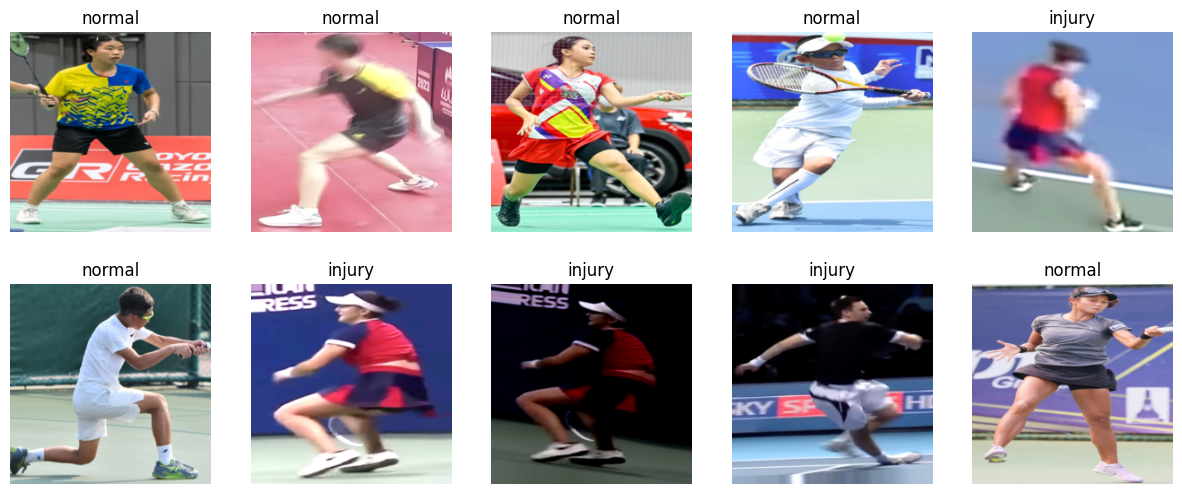

In [ ]:
fields = fields.new(item_tfms=Resize(224, method=ResizeMethod.Squish))
# dls = fields.dataloaders("/content/gdrive/MyDrive/data3/tr")
dls = fields.dataloaders("/content/drive/MyDrive/trainv3/")
dls.train.show_batch(max_n=10,nrows=2)

In [ ]:
fields = fields.new(item_tfms=Resize(200, method=ResizeMethod.Squish),batch_tfms=aug_transforms(p_lighting=1.0,p_affine=1.0,max_warp=0,max_lighting=0.4,min_zoom=1,max_zoom=1,max_rotate=10.0))
dls = fields.dataloaders("/content/gdrive/MyDrive/data/tr")
dls.train.show_batch(max_n=10,nrows=2,unique=True)

In [ ]:
# dls = fields.dataloaders("/content/gdrive/MyDrive/Colab Notebooks/data/tr/")
# dls = fields.dataloaders("/content/gdrive/MyDrive/data/tr")

In [ ]:
# get_image_files('/content/gdrive/MyDrive/Colab Notebooks/data/tr/')
get_image_files("/content/gdrive/MyDrive/data2/tr")

(#971) [Path('/content/gdrive/MyDrive/data2/tr/injury/aug_6_1180019.png'),Path('/content/gdrive/MyDrive/data2/tr/injury/aug_35_8934211.png'),Path('/content/gdrive/MyDrive/data2/tr/injury/aug_45_204059.png'),Path('/content/gdrive/MyDrive/data2/tr/injury/aug_38_3064121.png'),Path('/content/gdrive/MyDrive/data2/tr/injury/aug_9_8461194.png'),Path('/content/gdrive/MyDrive/data2/tr/injury/aug_4_8944949.png'),Path('/content/gdrive/MyDrive/data2/tr/injury/aug_78_4507960.png'),Path('/content/gdrive/MyDrive/data2/tr/injury/aug_12_8278741.png'),Path('/content/gdrive/MyDrive/data2/tr/injury/aug_72_3611470.png'),Path('/content/gdrive/MyDrive/data2/tr/injury/aug_18_9908892.png')...]

In [ ]:
dls.vocab

['injury', 'normal']

In [ ]:
batch = dls.train.one_batch()  # Get a batch of augmented images
images = batch[0]  # Extract the images from the batch

_, axs = plt.subplots(8, 8, figsize=(12, 10))
for i, ax in enumerate(axs.flatten()):
    show_image(images[i], ctx=ax)

plt.show()
print(len(batch[1]))

# dls.train.show_batch()

In [ ]:
dls.train.show_batch(max_n=100, nrows=9)

In [ ]:
dls.valid.show_batch(max_n=100, nrows=9)

In [ ]:
learner = vision_learner(dls, convnext_tiny, metrics=[error_rate, accuracy,Precision(),Recall(),F1Score(),RocAucBinary()])

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth
100%|██████████| 109M/109M [00:01<00:00, 109MB/s]


In [ ]:
learner.summary()

KeyboardInterrupt: ignored

In [ ]:
print(learner.summary())

Sequential (Input shape: 64 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 96 x 56 x 56   
Conv2d                                    4704       False     
LayerNorm2d                               192        True      
Conv2d                                    4800       False     
____________________________________________________________________________
                     64 x 56 x 56 x 96   
Permute                                                        
LayerNorm                                 192        True      
____________________________________________________________________________
                     64 x 56 x 56 x 384  
Linear                                    37248      False     
GELU                                                           
____________________________________________________________________________
                     64 x 56 x 56 x 96   
Linear                                    36

In [ ]:
import time

SuggestedLRs(valley=0.0006918309954926372)

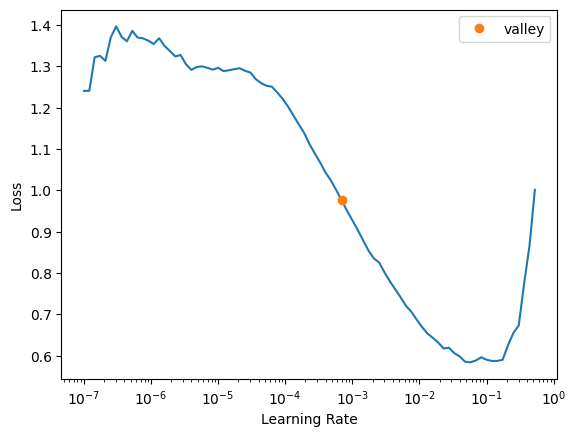

In [ ]:
learner.lr_find()

In [ ]:
t0 = time.time()
learner.fine_tune(epochs=25,base_lr= 0.0004 ,freeze_epochs=0) #t 1208.132461309433 0.997361 1850
# learner.fit_one_cycle(100,0.0004,cbs=EarlyStoppingCallback(monitor='valid_loss', min_delta=0.0001, patience=3))
print("Training time:", time.time()-t0)

epoch,train_loss,valid_loss,error_rate,accuracy,precision_score,recall_score,f1_score,roc_auc_score,time
0,0.884114,0.526680,0.234829,0.765172,0.781065,0.717391,0.747875,0.828679,03:36
1,0.617959,0.242754,0.097625,0.902375,0.950920,0.842391,0.893372,0.968813,01:03
2,0.431017,0.109172,0.044855,0.955145,0.977143,0.929348,0.952646,0.993813,01:00
3,0.311968,0.063883,0.015831,0.984169,0.994444,0.972826,0.983516,0.997742,01:04
4,0.226648,0.045012,0.013193,0.986807,1.000000,0.972826,0.986226,0.998690,01:00
5,0.165462,0.029063,0.007916,0.992084,1.000000,0.983696,0.991781,0.999666,01:00
6,0.126225,0.021414,0.005277,0.994723,1.000000,0.989130,0.994536,0.999889,01:02
7,0.092863,0.015856,0.002639,0.997361,1.000000,0.994565,0.997275,0.999972,01:04
8,0.072707,0.018684,0.005277,0.994723,1.000000,0.989130,0.994536,0.999944,00:59
9,0.055979,0.012902,0.002639,0.997361,1.000000,0.994565,0.997275,1.000000,01:01


Training time: 1717.7951800823212


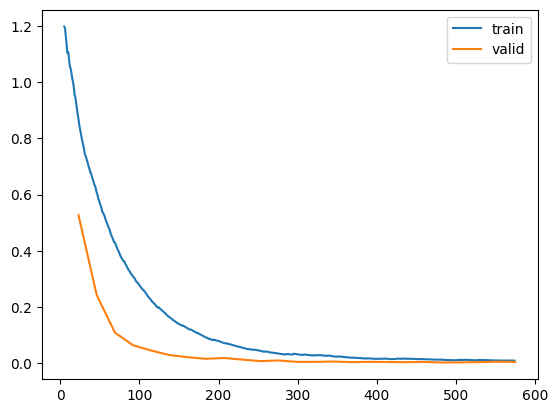

In [ ]:
learner.recorder.plot_loss()

In [ ]:
@patch
@delegates(subplots)
def plot_metrics(self: Recorder, nrows=None, ncols=None, figsize=None, **kwargs):
    metrics = np.stack(self.values)
    names = self.metric_names[1:-1]
    n = len(names) - 1
    if nrows is None and ncols is None:
        nrows = int(math.sqrt(n))
        ncols = int(np.ceil(n / nrows))
    elif nrows is None: nrows = int(np.ceil(n / ncols))
    elif ncols is None: ncols = int(np.ceil(n / nrows))
    figsize = figsize or (ncols * 6, nrows * 4)
    fig, axs = subplots(nrows, ncols, figsize=figsize, **kwargs)
    axs = [ax if i < n else ax.set_axis_off() for i, ax in enumerate(axs.flatten())][:n]
    for i, (name, ax) in enumerate(zip(names, [axs[0]] + axs)):
        ax.plot(metrics[:, i], color='#1f77b4' if i == 0 else '#ff7f0e', label='valid' if i > 0 else 'train')
        ax.set_title(name if i > 1 else 'losses')
        ax.legend(loc='best')
    plt.show()

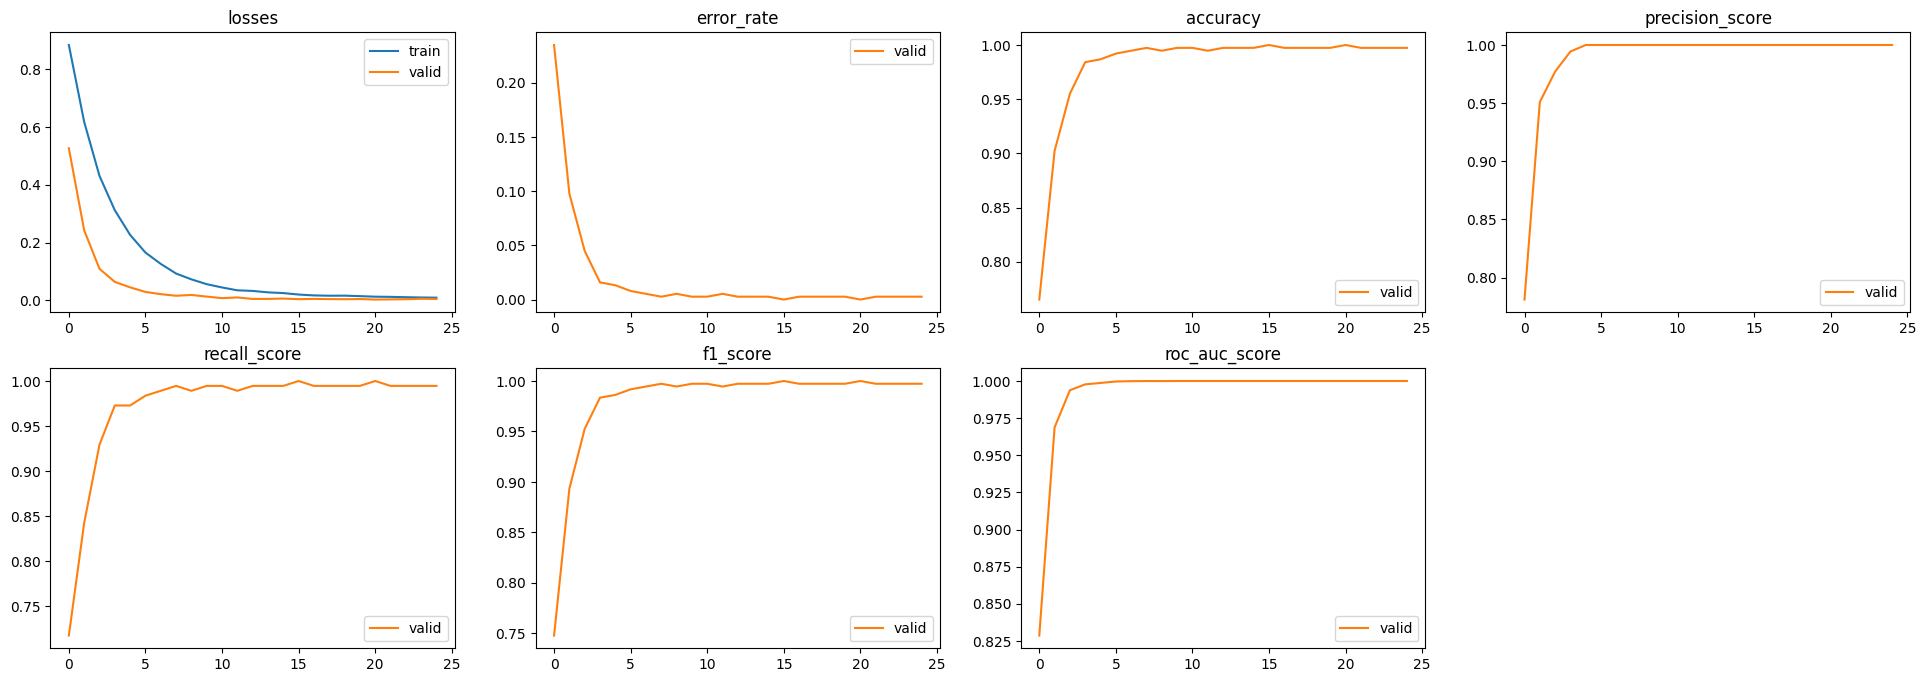

In [ ]:
learner.recorder.plot_metrics()

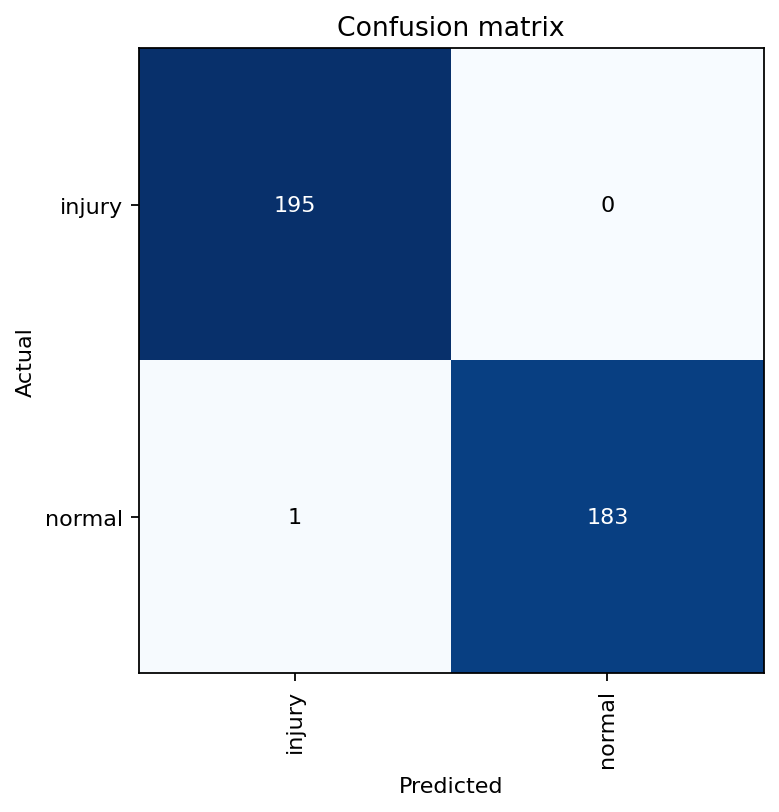

In [ ]:
interp = ClassificationInterpretation.from_learner(learner)
interp.plot_confusion_matrix(figsize=(5,5), dpi=160)

In [ ]:
interp.plot_top_losses(1, figsize=(5,5))

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


ValueError: ignored

In [ ]:
learner.show_results(max_n=15,shuffle=True)

Yahoo

In [ ]:
learner.export("convenxt_t.pkl")

In [ ]:
from fastbook import *
from glob import glob
from pathlib import Path
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, roc_auc_score

learn_inf = load_learner('/content/8_xresnet50_fastai_binary.pkl')

In [ ]:
tt=Image.open("/content/gdrive/MyDrive/Colab Notebooks/data/te/yahoo/n322.jpg").resize((224, 224))

In [ ]:
p=learn_inf.predict(tt)

In [ ]:
p=load_learner('/content/convenxt_t.pkl')

Testing time: 58.69247817993164


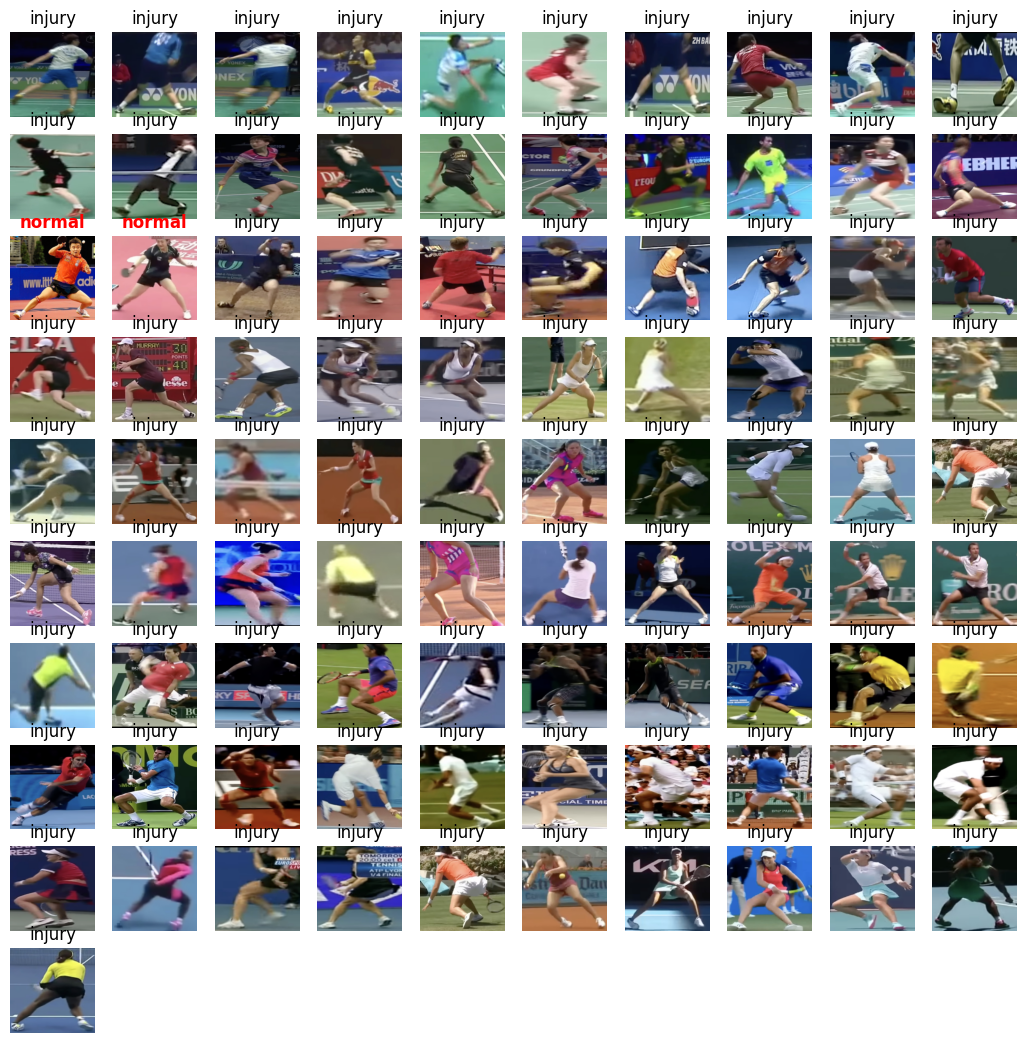

In [ ]:
t2 = time.time()
plt.figure(figsize=(13,13))
jj=('/content/drive/MyDrive/data3/te/injury/')
# jj=('/content/gdrive/MyDrive/Colab Notebooks/data2/te/yahoo/')
# p = os.listdir('data/')
c=0
for i in os.listdir(jj)[:91]:
    plt.subplot(10,10,c)
    img = Image.open(jj+i).resize((200, 200))
    # img1 = cv2.resize(img,(50,50))
    # img1 = img1.reshape(1,-1)/255
    # img1=np.array (img1).flatten()
    # img1=img1.convert("L")
    pred_class, pred_idx, outputs =p.predict(img)
    plt.title(pred_class) if pred_class == "injury" else plt.title(pred_class ,weight='bold',color='red')
    #plt.title(outputs[1],loc='right',size='small',style='italic', weight='bold')
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    c+=1
    #print(p)
print("Testing time:", time.time()-t2)
time_per_image = (time.time()-t2)/ c
print("Time per image:", time_per_image, "seconds")

In [ ]:
t1 = time.time()
plt.figure(figsize=(13,13))
jj=('/content/drive/MyDrive/data3/te/normal/')
# jj=('/content/drive/MyDrive/Colab Notebooks/data2/te/yahoo/')
# p = os.listdir('data/')
c=0
for i in os.listdir(jj)[:98]:
    plt.subplot(10,10,c)
    img = Image.open(jj+i).convert('RGB').resize((200, 200))
    # img1 = cv2.resize(img,(50,50))
    # img1 = img1.reshape(1,-1)/255
    # img1=np.array (img1).flatten()
    # img1=img1.convert("L")
    pred_class, pred_idx, outputs =p.predict(img)
    plt.title(pred_class) if pred_class == "normal" else plt.title(pred_class ,weight='bold',color='red')
    #plt.title(outputs[1],loc='right',size='small',style='italic', weight='bold')
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    c+=1
    #print(p)
print("Testing time:", time.time()-t1)
time_per_image = (time.time()-t1)/ c
print("Time per image:", time_per_image, "seconds")

Output hidden; open in https://colab.research.google.com to view.